This seeks to implement the recurisve brute force for ${}^{151}$Pr:Y${}_{2}$SiO$_{5}$, as per Elliot Fravals thesis and [this](10.1103/PhysRevLett.92.077601) work.

Pr has no Electronic spin and a nuclear spin of $\frac{5}{2}$. This works focuses on site one with a $C_{1}$ symmetry.
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [17]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle

In [18]:
plt.rc('xtick', labelsize=16) 
plt.rc('ytick', labelsize=16) 
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)

In [19]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [20]:
#M tensor ground state
M = np.matrix(np.diag([2.86,3.05,11.56]))*10/muNf# Convert from kHz/G to MHz/T and then divide by MuNf
#Q tensor ground state
Q = np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))

#rotated tensors
M_rot = np.array([-99.7,55.7,-40])*np.pi/180
# Q_rot = M_rot
Q_rot = np.array([-94,58.1,-20.7])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str='ZYZ')
Q_G = spin.tensorRotation(Q,Q_rot,str='ZYZ')

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
ground.setM(M_G)
#print(ground.H.shape)



[[-0.5624  0.      0.    ]
 [ 0.      0.5624  0.    ]
 [ 0.      0.      4.445 ]]
Q [[ 0.40747302 -0.00924087 -0.46728936]
 [-0.00924087  3.10033234 -2.15607217]
 [-0.46728936 -2.15607217  0.93719464]]
M [[ 4.09319568  1.2094972  -0.98709479]
 [ 1.2094972  11.37875701 -5.17297102]
 [-0.98709479 -5.17297102  7.44675667]]


In [21]:

#
Is = spin.spinOperator(Ispin,matricies=True)
As = spin.genAMatrix(M_G,Is)

def singleLoop(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
        Fp.append(v)
    Fp = np.array(Fp).T
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG)#*spin.muN
    Fpp = 1
    return (F,Fp,Fpp)


#our loop
def sweep(Bx,By,Bz):
    #sets the default dynamic term as both electronic and nuclear zeeman
    F = ground.initSweep(Bx,By,Bz)
    Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    Fpp = ground.initSweep(Bx,By,Bz,ground.dim)

    for i in range(len(Bx)):
        for j in range(len(By)):
            for k in range(len(Bz)):
                F[i,j,k,:],Fp[i,j,k,:],Fpp[i,j,k,:] = singleLoop(Bx[i],By[j],Bz[k])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=3),spin.eachElemFunc(Fp,Fp,ax=3),spin.eachElemFunc(Fpp,Fpp,ax=3)


def initGradDescent(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG)#*spin.muN
    return (F,Fpp)

maxmin = lambda x:np.max(np.abs([np.max(x),np.min(x)]))


def printRegionsXY(CR):
    for R in CR:
        #print(R)
        h=R[1][1]-R[1][0]
        w = R[0][1]-R[0][0]
        #print(R[0:1][0],w,h)
        ax=plt.gca()
        ax.add_patch(Rectangle([R[0][0],R[1][0]],w,h,fill=False))

In [22]:
pts =50

np.set_printoptions(threshold=np.inf)

Bxi = np.linspace(0,0.02,pts)
Byi = Bxi
Bzi = Bxi

delta = (Bxi[-1]-Bxi[0])/len(Bxi)


Fi,Fip,Fipp=sweep(Bxi,Byi,Bzi)


In [23]:

Idi = spin.ZEFOZidx(Fip)
print(Idi.shape)
Idu = np.unique(Idi[:,0:3],axis=0)
print("Initial Run Found: "+str(Idi.shape[0])+" Points at "+str(Idu.shape[0])+" Magnetic field orientations")



(114, 4)
Initial Run Found: 114 Points at 4 Magnetic field orientations


In [24]:
#Idi = np.matrix(Idi)

def findInterestingTZ(Idi,T=None,Z=None):
    u,c = np.unique(Idi[:,3],return_counts=True)
    idx = np.argsort(c)
    print(u[idx],c[idx])
        
    if T==None:
        T = u[np.argmin(c)]
    if Z==None:
        Tnum = np.matrix(Idi[np.where(Idi[:,3]==T),:])
        u,c = np.unique(Tnum[:,2],return_counts=True,axis=0)
        Z=u[np.argmax(c)].item()
    ZP = Tnum[np.where(Tnum[:,2]==Z),:][0]
    print(T,Z)
    return T,Z,ZP

T,Z,ZP=findInterestingTZ(Idi,T=None)

print(ZP,ZP.shape)
Xs = ZP[:,0]
Ys = ZP[:,1]

BZP = np.array([Bxi[ZP[:,0]],Byi[ZP[:,1]],Bzi[ZP[:,2]]]).T


#print(Xs,Ys)
#print(np.diff(ZP[:,0:4],axis=0))
#Cn=np.argwhere(np.all(np.abs(np.diff(ZP[:,0:4],axis=0))<=1,axis=1))[:,0]
#spid=np.argwhere(np.abs(np.diff(ZP[:,0:4],axis=0))>1)[:,0].flatten()+1
#print(spid)
#print(np.split(ZP,spid,axis=0))
CR=spin.connectedRegion(ZP)

print(CR)

[34 29 26 23 16 33 32 31 30 27 25 24 22 20 19  1 15 13 12 11 10  9  8  6
  5  4  3  2 18 17] [3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
16 1
[[ 0  0  1 16]
 [ 0  1  1 16]] (2, 4)
[[[0, 1], [0, 2], [1, 2]]]


In [25]:

print(BZP*1E4)

print([np.linalg.norm(B,axis=1) for B in BZP])


[[[0.         0.         4.08163265]
  [0.         4.08163265 4.08163265]]]
[array([0.00040816, 0.00057723])]


(3, 3)
[[0 4]
 [0 0]]


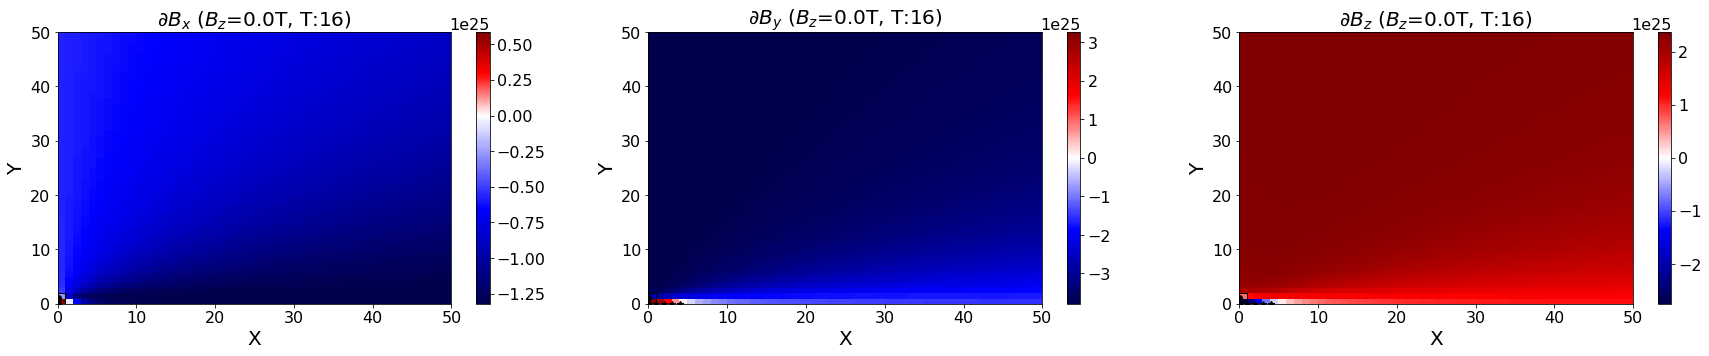

In [26]:
%matplotlib inline

#Z=11
#T = 10

Fpx =(Fip[:,:,Z,T,0])
Fpy =(Fip[:,:,Z,T,1])
Fpz =(Fip[:,:,Z,T,2])
        


cnorm = clr.TwoSlopeNorm(vcenter=0)
normCZero = lambda x: clr.TwoSlopeNorm(vmin=np.min(x),vmax=np.max(x),vcenter=0)
normSZero = lambda x: clr.TwoSlopeNorm(vmin=0,vmax=np.max(x),vcenter=np.max(x)/2)
#vmin=np.min(x),vmax=np.max(x)

fig = plt.figure(figsize=(30,5))

plt.set_cmap('seismic')
ax = plt.subplot(1,3,1)

#print(Fpx)

ZCxx= spin.zero_crossings(Fip[:,:,Z,T,:],0)
print(ZCxx.shape)
#ZCxx[:,0]+=1
ZCyy= spin.zero_crossings(Fip[:,:,Z,T,:],1)
#ZCyy[:,1]+=1

#ZCzz= spin.zero_crossings(Fip[:,:,Z,T,:],0)

ZC=np.vstack([ZCxx,ZCyy])
#ZC = ZCxx
#print(ZC)
#print(ZC)
ZCx = ZC[np.where(ZC[:,2]==0)]
ZCy = ZC[np.where(ZC[:,2]==1)]
ZCz = ZC[np.where(ZC[:,2]==2)]

x_u,i_s,y_s=np.unique(ZC[:,0:2],axis=0,return_counts=True,return_index=True)
zf = np.argwhere(y_s>=3)
zf = x_u[zf[:,0],:]

#pstr = ["%s(%s), "%(x_u[i],y_s[i]) for i in range(len(x_u))]
#print(pstr)
print(zf.T)

#print(ZCx)

        
plt.pcolor(np.real(Fpx).T,norm=normCZero(np.real(Fpx)))
plt.plot(ZCx[:,0],ZCx[:,1],'k*')
#plt.plot(zf[:,0],zf[:,1],'k*')
plt.plot(Xs,Ys,'ko')
printRegionsXY(CR)

plt.title(r"$\partial B_{x}$"+r" ($B_{z}$=%sT, T:%s)"%(round(Bzi[Z],3),T))
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

ax = plt.subplot(1,3,2)


plt.pcolor(np.real(Fpy).T,norm=normCZero(np.real(Fpy)))
plt.plot(ZCy[:,0],ZCy[:,1],'k*')
plt.plot(Xs,Ys,'ko')
printRegionsXY(CR)

#
plt.title(r"$\partial B_{y}$"+r" ($B_{z}$=%sT, T:%s)"%(round(Bzi[Z],3),T))

plt.xlabel("X")
plt.ylabel("Y") 
plt.colorbar()

ax = plt.subplot(1,3,3)
plt.pcolor(np.real(Fpz).T,norm=normCZero(np.real(Fpz)))
plt.plot(ZCz[:,0],ZCz[:,1],'k*')
plt.plot(Xs,Ys,'ko')
printRegionsXY(CR)

#plt.plot(zf[:,0],zf[:,1],'k*')

#plt.plot(Xs,Ys,'k*')
plt.title(r"$\partial B_{z}$"+r" ($B_{z}$=%sT, T:%s)"%(round(Bzi[Z],3),T))

plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

#plt.ylim([-0.005,0.005])
plt.savefig("../images/gradients.pgf",bbox_inches='tight')
plt.savefig("../images/gradients.pdf",bbox_inches='tight')
plt.show()
plt.close()

#print(np.real(Fpz))
#print(np.sign(Fpz))
#print(np.diff(np.sign(Fpz),axis=0).T)
#print(np.argwhere(np.diff(np.sign(Fpz),axis=0).T))

(50, 50)
[4.7804100e+24 5.3141559e+24 6.9784142e+24 7.9885291e+24 8.1277075e+24]


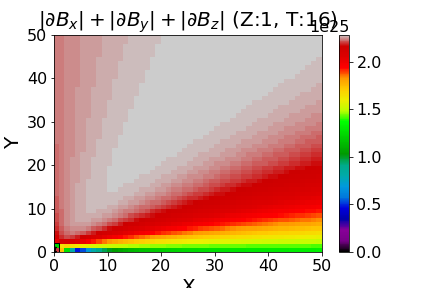

In [27]:
%matplotlib widget

Fsum = np.real(np.abs(Fpx)+np.abs(Fpy)+np.abs(Fpz))/3
#Fsum =np.real(Fpx+Fpy+Fpz)
#plt.pcolor(Bxi,Byi,Fsum.T,cmap='nipy_spectral',norm=normSZero(Fsum),shading='auto')
plt.pcolor(Fsum.T,cmap='nipy_spectral',norm=normSZero(Fsum),shading='auto')
#plt.plot(zf[:,0],zf[:,1],'k*',markersize=2)

#plt.plot(Bxi[zf[:,0]],Byi[zf[:,1]],'k*',markersize=2)
#plt.plot(Bxi[Xs],Byi[Ys],'k*',markersize=5)
plt.plot(Xs,Ys,'k*',markersize=5)
printRegionsXY(CR)

plt.xlabel("X")
plt.ylabel("Y")
plt.title(r"$|\partial B_{x}|+|\partial B_{y}|+|\partial B_{z}|$"+" (Z:%s, T:%s)"%(Z,T))
plt.colorbar()
print(Fsum.shape)
k=5
print(np.sort(Fsum.flatten())[:k])
# x,y,z = np.meshgrid(Bxi,Byi,Bzi)
# np.vectorize(singleLoop)(x,y,z)
# ret = np.frompyfunc(singleLoop,3,3)(x,y,z)
# print(ret.shape)
plt.savefig("../images/sum_gradients.png",bbox_inches='tight')
plt.show()

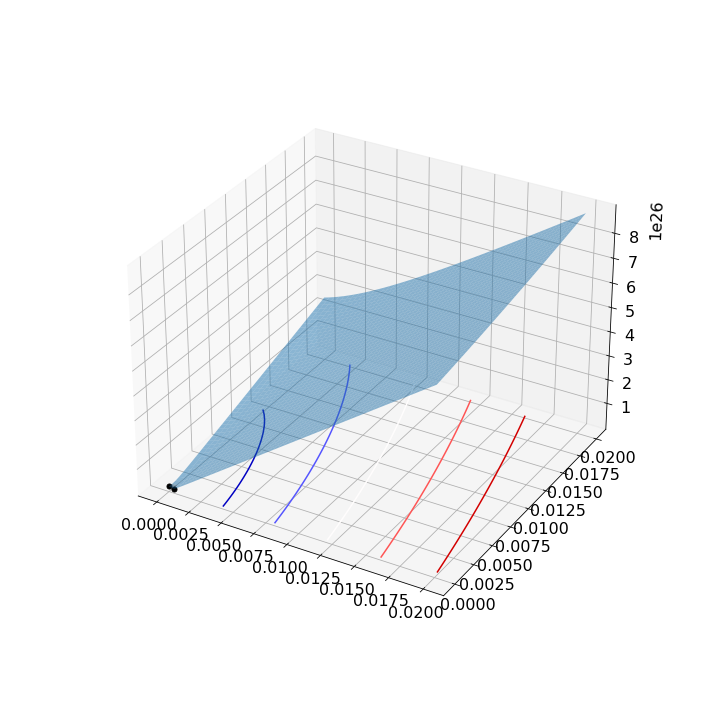

In [28]:
%matplotlib widget
X,Y=np.meshgrid(Bxi,Byi)
fig = plt.figure(figsize=(10,10))


#ax = fig.subplot(1,3,1)
ax = fig.add_subplot(projection='3d')

#print(Fi.shape)

#for i in range(int(Fi.shape[3]/4)):
ax.plot_surface(X,Y,np.real(Fi[:,:,Z,T]),alpha=0.5)
ax.contour(X,Y,np.real(Fi[:,:,Z,T]),offset=-1)
ax.plot(Byi[Ys].flatten(),Bxi[Xs].flatten(),np.real(Fi[Xs,Ys,Z,T]).flatten(),'ok',markersize=5)
#plt.plot(Xs,Ys,'*')
#print(Fi[Xs,Ys,Z,T])
#plt.legend()
#,cmap='nipy_spectral'

plt.show()
#plt.close()


ZEFOZ point:  [[ 0  0  1 16]]


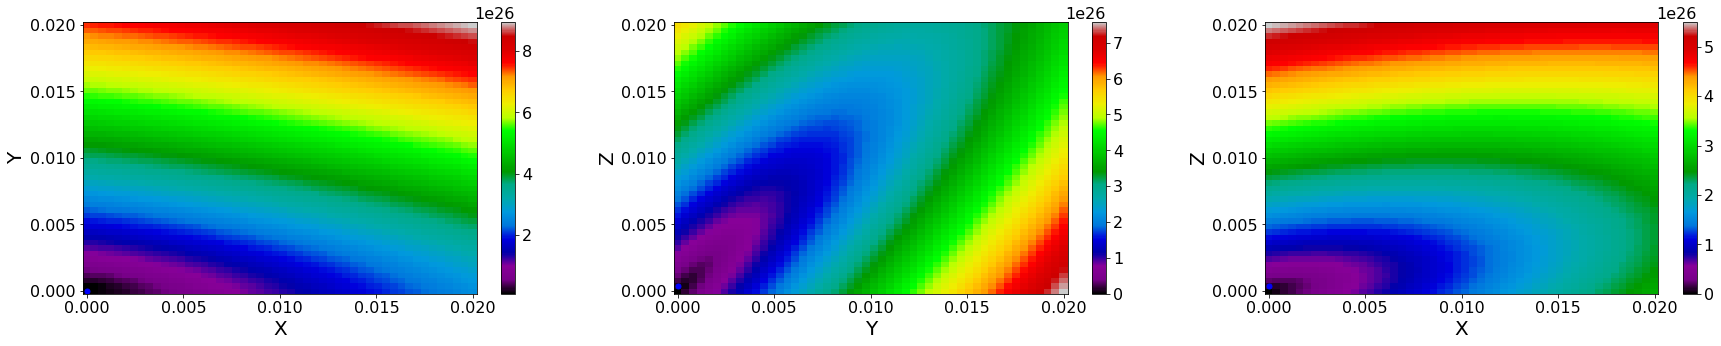

In [29]:
%matplotlib inline
X,Y=np.meshgrid(Bxi,Byi)

ZPnum= 0
print("ZEFOZ point: ", ZP[ZPnum,:])

fig = plt.figure(figsize=(30,5))
plt.set_cmap('nipy_spectral')

marker_style = dict(color='b', marker='o',
                    markersize=5)

ax = plt.subplot(1,3,1)
plt.pcolor(X,Y,np.real(Fi[:,:,ZP[ZPnum,2],T]).T,cmap='nipy_spectral',shading='auto')
plt.plot(Bxi[ZP[ZPnum,0]],Byi[ZP[ZPnum,1]],**marker_style)
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

ax = plt.subplot(1,3,2)
plt.pcolor(X,Y,np.real(Fi[ZP[ZPnum,0],:,:,T]).T,cmap='nipy_spectral',shading='auto')
plt.plot(Bxi[ZP[ZPnum,1]],Byi[ZP[ZPnum,2]],**marker_style)
plt.xlabel("Y")
plt.ylabel("Z")
plt.colorbar()

ax = plt.subplot(1,3,3)
plt.pcolor(X,Y,np.real(Fi[:,ZP[ZPnum,1],:,T]).T,cmap='nipy_spectral',shading='auto')
plt.plot(Bxi[ZP[ZPnum,0]],Byi[ZP[ZPnum,2]],**marker_style)
plt.xlabel("X")
plt.ylabel("Z")

plt.colorbar()

#for i in range(int(Fi.shape[3]/4)):
#ax.plot_surface(X,Y,np.real(Fi[:,:,Z,T]))



#plt.legend()

plt.show()
#plt.close()


In [30]:
#raise SystemExit("Stop! You've Violated the Law!")


In [31]:
#%matplotlib inline

Fs = []
Fps=[]
Fpps=[]
##ids=[]
Bs = []

Idu=Idi[np.where(Idi[:,3]==T),:][0]
#print(Idu)
print(len(CR),CR)
fig = plt.figure(figsize=(30,5))
k=0
for R in CR:
    print(R,R[0][1],R[2][1])
    # Bx = np.linspace(Bxi[i[0]],Bxi[i[0]]+delta,pts)
    # By = np.linspace(Byi[i[1]],Byi[i[1]]+delta,pts)
    # Bz = np.linspace(Bzi[i[2]],Bzi[i[2]]+delta,pts)
    Bx = np.linspace(Bxi[R[0][0]],Bxi[R[0][1]],pts)
    By = np.linspace(Byi[R[1][0]],Byi[R[1][1]],pts)
    Bz = np.linspace(Bzi[R[2][0]],Bzi[R[2][1]],pts)
    
    # #print(Bx)
    F,Fp,Fpp = sweep(Bx,By,Bz)
        
    id = spin.ZEFOZidx(Fp)
    #print(F.shape,print(tid))
    #print(id)
    if id.size>0:
        tid= tuple(id.T)
        print(id,Bx[id[:,0]])
        #zx = spin.zero_crossings(Fp,ax=3)
        #print(zx)
        #print(zx[7,2,7,:,:])

        # Fs.append(F[tid])
        # Fps.append(Fp[tid])
        # Fpps.append(Fpp[tid])
        # Bs.append([Bx[id[:,0]],By[id[:,1]],Bz[id[:,2]]])
        # #plt.plot(np.real(Fp[:,7,0,29,0]),'r*-')
        #plt.plot(np.real(Fp[8,:,0,29,1]),'g*-')
        #plt.plot(np.real(Fp[8,7,:,29,2]),'b*-')
        #plt.plot(np.zeros(Fp.shape[0]))
        plt.set_cmap('seismic')
        ax = plt.subplot(1,3,1)
        #idx= np.ndindex((:,:,6,22))
        T,Z,ZP=findInterestingTZ(id)

        Ft = F[:,:,Z,T]
        Fpx =Fp[:,:,Z,T,0]
        Fpy =Fp[:,:,Z,T,1]
        Fpz =Fp[:,:,Z,T,2]
        

        cnorm = lambda x: clr.TwoSlopeNorm(vcenter=0)
        #vmin=np.min(x),vmax=np.max(x)
        plt.pcolor(np.real(Fpx).T,norm=cnorm(Fpx))
        plt.plot(ZP[:,0],ZP[:,1],'k*')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.colorbar()

        ax = plt.subplot(1,3,2)
        plt.pcolor(np.real(Fpy).T,norm=cnorm(Fpy))
        plt.plot(ZP[:,0],ZP[:,1],'k*')
        plt.xlabel("X")
        plt.ylabel("Z") 
        plt.colorbar()

        ax = plt.subplot(1,3,3)
        plt.pcolor(np.real(Fpz).T,norm=cnorm(Fpz))
        plt.plot(ZP[:,0],ZP[:,1],'k*')
        plt.xlabel("Y")
        plt.ylabel("Z")
        plt.colorbar()

        #plt.ylim([-0.005,0.005])
        
        plt.show()
        plt.close()
        break
    else:
        k+=1
        print("%s False Positives"%k)
    #print(Bs)

print(len(Fs))

1 [[[0, 1], [0, 2], [1, 2]]]
[[0, 1], [0, 2], [1, 2]] 1 2
1 False Positives
0


<Figure size 2160x360 with 0 Axes>

In [32]:
raise SystemExit("Stop! You've Violated the Law!")


SystemExit: Stop! You've Violated the Law!

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3449: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


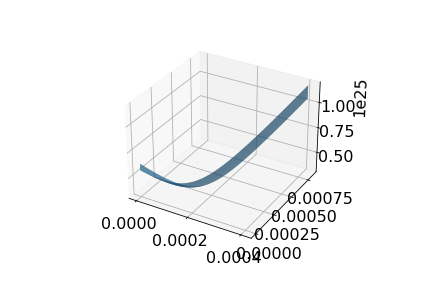

<function matplotlib.pyplot.close(fig=None)>

In [ ]:
%matplotlib widget
ax = plt.axes(projection='3d')
ax.plot_surface(Bx,By,np.real(F[:,:,6,22]))
plt.show()
plt.close
        

In [ ]:
print(np.concatenate(Fpps).shape)
print(Fpps)
#print(Bs)
#print(Idi)
#print(Idi[:,0:3])


ValueError: need at least one array to concatenate

In [ ]:
OS = Fip
CS = Fipp#np.abs(spin.eachElemFunc(CS_G,CS_G,ax=3))

#np.savez("1E-1_linear_grid",FG,OS_SG,CS_G)
ps = spin.zero_crossings(OS,2)
print(ps.shape)
id = spin.ZEFOZidx(OS,2)

print(id.shape)
print(id[0])
u,c = np.unique(id[:,3],return_counts=True)

print(u,c)
#print((Bs[-1]-Bs[0])/len(Bs))


# B = np.sqrt(Bs[id[:,0]]**2+Bs[id[:,1]]**2+Bs[id[:,2]]**2)

# C = np.array([1.77,-0.63,-0.45])
# Cn =np.linalg.norm(C)*1E4
# print(Cn)

# plt.loglog(CS[tuple(id.T)]*1E1,B*1E4,'+')
# plt.loglog(np.logspace(-2,6,10),Cn*np.ones(10),'r--')
# plt.ylabel(r'$Field(G)$')
# plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
# plt.xlim([1E-2,1E6])
# plt.ylim([1E2,1E6])
# plt.xticks([1E-2,1E0,1E2,1E4,1E6])
# plt.grid()
# plt.show()
# plt.close()




(123080, 5)
(114, 4)
[0 0 0 1]
[ 1  2  3  4  5  6  8  9 10 11 12 13 15 16 17 18 19 20 22 23 24 25 26 27
 29 30 31 32 33 34] [4 4 4 4 4 4 4 4 4 4 4 4 4 4 3 4 4 4 3 4 4 4 4 3 3 4 4 3 4 3]
